In [5]:
!pip install pandas numpy matplotlib seaborn scikit-learn

Перші рядки таблиці:
   Unnamed: 0  price      brand    model  year   title_status   mileage  \
0           0   6300     toyota  cruiser  2008  clean vehicle  274117.0   
1           1   2899       ford       se  2011  clean vehicle  190552.0   
2           2   5350      dodge      mpv  2018  clean vehicle   39590.0   
3           3  25000       ford     door  2014  clean vehicle   64146.0   
4           4  27700  chevrolet     1500  2018  clean vehicle    6654.0   

    color                  vin        lot       state country      condition  
0   black    jtezu11f88k007763  159348797  new jersey     usa   10 days left  
1  silver    2fmdk3gc4bbb02217  166951262   tennessee     usa    6 days left  
2  silver    3c4pdcgg5jt346413  167655728     georgia     usa    2 days left  
3    blue    1ftfw1et4efc23745  167753855    virginia     usa  22 hours left  
4     red    3gcpcrec2jg473991  167763266     florida     usa  22 hours left  

Інформація про таблицю:
<class 'pandas.core.frame.Dat

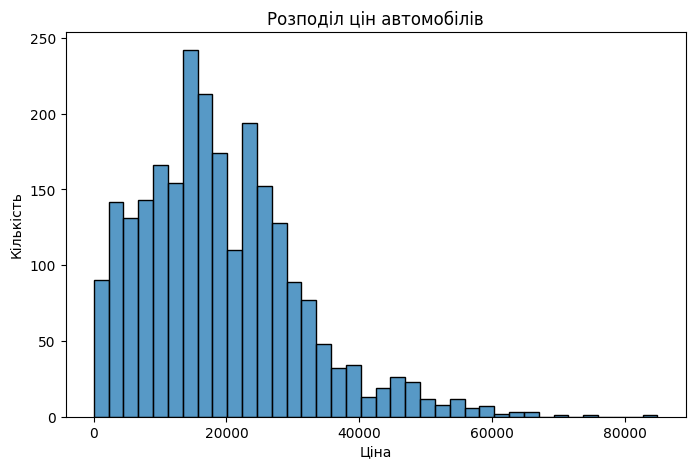

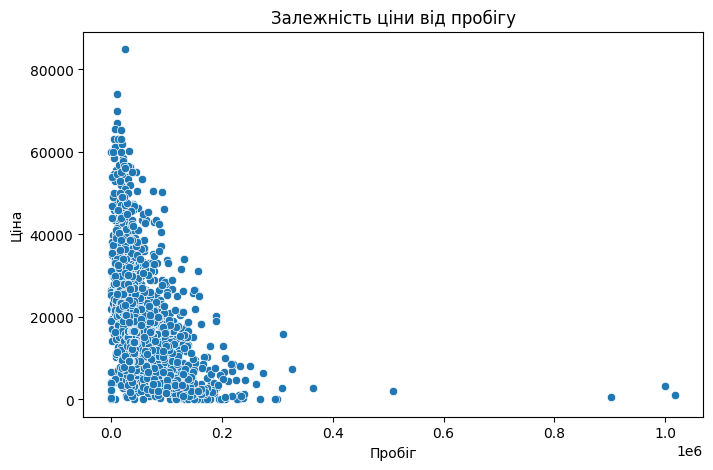


X:
       brand    model  year   mileage   color       state
0     toyota  cruiser  2008  274117.0   black  new jersey
1       ford       se  2011  190552.0  silver   tennessee
2      dodge      mpv  2018   39590.0  silver     georgia
3       ford     door  2014   64146.0    blue    virginia
4  chevrolet     1500  2018    6654.0     red     florida

y:
0     6300
1     2899
2     5350
3    25000
4    27700
Name: price, dtype: int64

Числові колонки: ['year', 'mileage']
Текстові колонки: ['brand', 'model', 'color', 'state']

Розмір train: (1964, 6)
Розмір test: (492, 6)

RandomForestRegressor:
MSE: 46019947.641688496
RMSE: 6783.800383390456
R2 на тестових даних: 0.6759317522380759

Cross-validation:
R2 scores: [0.19788614 0.4545663  0.55066415 0.48167062 0.42233749]
Середній R2: 0.4214249395520947

Порівняння моделей:

Модель: LinearRegression
R2 на тесті: 0.7068564322699686
Середній R2 при cross-validation: 0.4339285416244626

Модель: RandomForestRegressor
R2 на тесті: 0.6759317522380

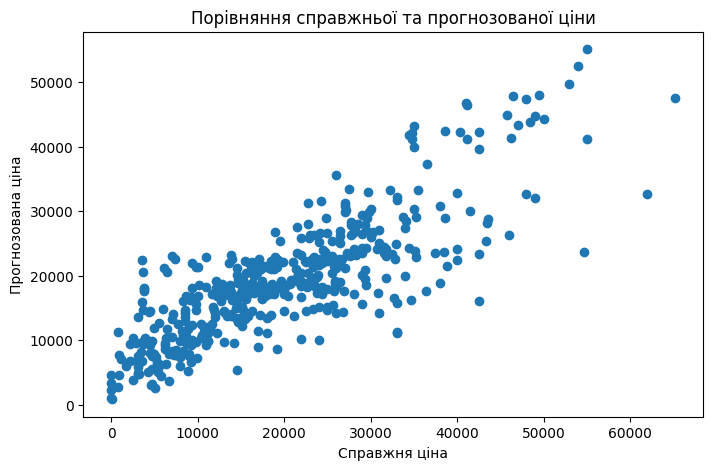

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


# ---------------- Завантаження даних ----------------

df = pd.read_csv("USA_cars_datasets.csv")

print("Перші рядки таблиці:")
print(df.head())

print("\nІнформація про таблицю:")
print(df.info())

print("\nСтатистика:")
print(df.describe())


# ---------------- Очищення даних ----------------

# Видаляємо зайві колонки
# state залишаємо, бо штат може впливати на ціну автомобіля
df = df.drop(
    ['Unnamed: 0', 'title_status', 'vin', 'lot', 'country', 'condition'],
    axis=1
)

# Видаляємо машини з ціною 0
df = df[df["price"] > 0]

print("\nКолонки після очищення:")
print(df.columns)

print("\nПропущені значення:")
print(df.isnull().sum())


# ---------------- Простий аналіз даних ----------------

plt.figure(figsize=(8, 5))
sns.histplot(df["price"])
plt.title("Розподіл цін автомобілів")
plt.xlabel("Ціна")
plt.ylabel("Кількість")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(x=df["mileage"], y=df["price"])
plt.title("Залежність ціни від пробігу")
plt.xlabel("Пробіг")
plt.ylabel("Ціна")
plt.show()


# ---------------- Вибір X та y ----------------

target = "price"

X = df.drop(target, axis=1)
y = df[target]

print("\nX:")
print(X.head())

print("\ny:")
print(y.head())


# ---------------- Числові та текстові колонки ----------------

num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(include="object").columns

print("\nЧислові колонки:", list(num_cols))
print("Текстові колонки:", list(cat_cols))


# ---------------- Підготовка даних ----------------

num_process = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_process = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", num_process, num_cols),
    ("cat", cat_process, cat_cols)
])


# ---------------- Розділення даних ----------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("\nРозмір train:", X_train.shape)
print("Розмір test:", X_test.shape)


# ---------------- Модель RandomForest ----------------

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

full_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", model)
])

full_model.fit(X_train, y_train)

y_pred = full_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nRandomForestRegressor:")
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 на тестових даних:", r2)


# ---------------- Cross-validation ----------------

scores = cross_val_score(full_model, X, y, cv=5, scoring="r2")

print("\nCross-validation:")
print("R2 scores:", scores)
print("Середній R2:", scores.mean())


# ---------------- Порівняння моделей ----------------

models = [
    LinearRegression(),
    RandomForestRegressor(
        n_estimators=300,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    )
]

print("\nПорівняння моделей:")

for m in models:
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", m)
    ])

    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    r2_model = r2_score(y_test, pred)
    scores_model = cross_val_score(pipe, X, y, cv=5, scoring="r2")

    print("\nМодель:", m.__class__.__name__)
    print("R2 на тесті:", r2_model)
    print("Середній R2 при cross-validation:", scores_model.mean())


# ---------------- Графік прогнозів ----------------

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred)
plt.xlabel("Справжня ціна")
plt.ylabel("Прогнозована ціна")
plt.title("Порівняння справжньої та прогнозованої ціни")
plt.show()


Висновок

У практичній роботі було створено модель машинного навчання для прогнозування ціни автомобіля за характеристиками. Для роботи використовувався датасет USA Cars. Цільовою змінною була колонка price.

Спочатку було завантажено дані, переглянуто перші рядки, типи даних та статистичну інформацію. Після цього були видалені зайві колонки, які не використовувалися для прогнозування.

Для числових ознак використовувалося заповнення пропусків медіаною та масштабування StandardScaler. Для текстових ознак використовувалося кодування OneHotEncoder. Для організації підготовки даних використовувалися Pipeline та ColumnTransformer.

Було протестовано дві моделі: LinearRegression та RandomForestRegressor. Кращий результат на тестових даних показала модель RandomForestRegressor. Також була виконана крос-валідація з 5 фолдами для перевірки стабільності моделі.

Можна зробити висновок, що модель RandomForestRegressor краще підходить для цього набору даних, тому що вона може враховувати складніші залежності між характеристиками автомобіля та його ціною.